In [1]:
import os

import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

In [2]:
INPUT_DIR = "/n/groups/kirschner/Will/BedRest/geseca"

In [3]:
sns.set_theme(context="paper", style="whitegrid")

# GO BP

In [4]:
pre = pd.read_csv(os.path.join(INPUT_DIR, "bp_pre.csv"))
post = pd.read_csv(os.path.join(INPUT_DIR, "bp_post.csv"))
both = pd.read_csv(os.path.join(INPUT_DIR, "bp.csv"))

In [5]:
pre_post = pd.merge(pre, post, on="pathway", suffixes=("_pre", "_post"), how="outer")
print(pre_post.shape)
# pre_post = pd.merge(pre_post, both, on="pathway", how="outer")
# print(pre_post.shape)

(3900, 11)


In [6]:
pval_threshold = 0.05

pre_post = pre_post.loc[(pre_post.padj_pre < pval_threshold) | (pre_post.padj_post < pval_threshold),:]

col = f"<>{pval_threshold}"
pre_post[col] = f">={pval_threshold}"
pre_post.loc[(pre_post.padj_pre < pval_threshold) & (pre_post.padj_post >= pval_threshold), col] = f"pre<{pval_threshold}"
pre_post.loc[(pre_post.padj_pre >= pval_threshold) & (pre_post.padj_post < pval_threshold), col] = f"post<{pval_threshold}"
pre_post.loc[(pre_post.padj_pre < pval_threshold) & (pre_post.padj_post < pval_threshold), col] = f"<{pval_threshold}"


# col_both = f"both<>{pval_threshold}"
# pre_post[col_both] = f"<{pval_threshold}"
# pre_post.loc[pre_post.padj >= pval_threshold, col_both] = f"both>={pval_threshold}"

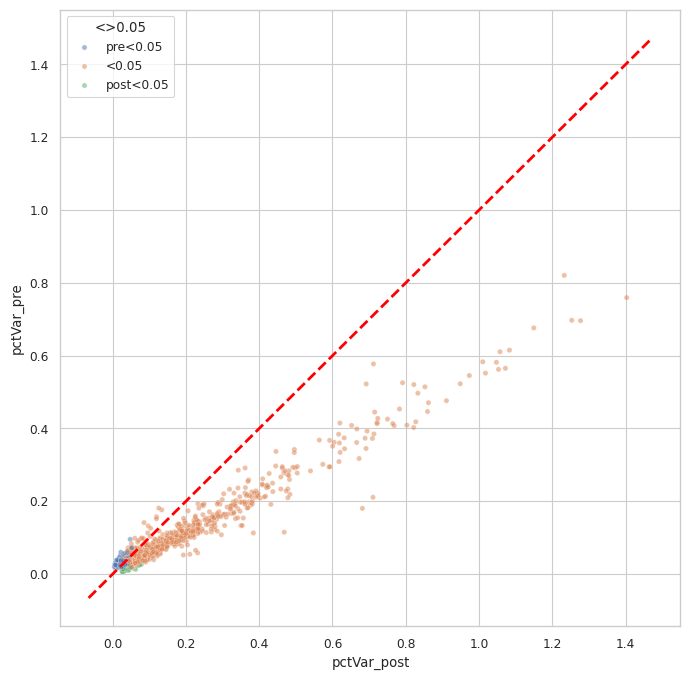

In [9]:
fig, axs = plt.subplots(1, 1, figsize=(8, 8))
sns.scatterplot(pre_post, x="pctVar_post", y="pctVar_pre", ax=axs, hue=col, s=14, alpha=0.5)
x_min, x_max = axs.get_xlim()
y_min, y_max = axs.get_ylim()
min_val = min(x_min, y_min)
max_val = max(x_max, y_max)

axs.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2)

# sns.scatterplot(pre_post, x="pctVar_post", y="pctVar_pre", ax=axs[1], hue=col_both, s=14, alpha=0.5)
# x_min, x_max = axs[1].get_xlim()
# y_min, y_max = axs[1].get_ylim()
# min_val = min(x_min, y_min)
# max_val = max(x_max, y_max)

# axs[1].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2)

In [10]:
with pd.option_context('display.max_colwidth', None, 'display.width', 1000):
    print(pre_post.loc[(pre_post.padj_pre < pval_threshold) & (pre_post.padj_post >= pval_threshold), :].sort_values("padj_pre").head(30))

                                                                   pathway  pctVar_pre      pval_pre      padj_pre  log2err_pre  size_pre  pctVar_post  pval_post  padj_post  log2err_post  size_post    <>0.05
784                                      GOBP_FATTY_ACID_METABOLIC_PROCESS    0.095396  7.078569e-08  3.305790e-07     0.704976       349     0.047844   0.069930   0.177788      0.166934        349  pre<0.05
3595                                 GOBP_SMALL_MOLECULE_CATABOLIC_PROCESS    0.071830  5.772218e-06  1.835374e-05     0.610527       333     0.051779   0.032967   0.102693      0.248911        333  pre<0.05
783                           GOBP_FATTY_ACID_DERIVATIVE_METABOLIC_PROCESS    0.059922  9.378443e-06  2.834608e-05     0.593325        73     0.022200   0.074925   0.186120      0.160801         73  pre<0.05
2610                           GOBP_PURINE_NUCLEOTIDE_BIOSYNTHETIC_PROCESS    0.061140  1.368551e-05  3.975597e-05     0.593325       171     0.039506   0.027972   0.09

In [11]:
with pd.option_context('display.max_colwidth', None, 'display.width', 1000):
    print(pre_post.loc[(pre_post.padj_pre >= pval_threshold) & (pre_post.padj_post < pval_threshold), :].sort_values("padj_post").head(30))

                                                                  pathway  pctVar_pre  pval_pre  padj_pre  log2err_pre  size_pre  pctVar_post  pval_post  padj_post  log2err_post  size_post     <>0.05
2944             GOBP_REGULATION_OF_INTRINSIC_APOPTOTIC_SIGNALING_PATHWAY    0.023838  0.029970  0.081851     0.261664       174     0.072280   0.000701   0.001313      0.477271        174  post<0.05
921                                     GOBP_HEMOGLOBIN_METABOLIC_PROCESS    0.012786  0.080919  0.163600     0.154191        18     0.062683   0.001003   0.001800      0.455060         18  post<0.05
3424                                           GOBP_RESPONSE_TO_METAL_ION    0.026656  0.044955  0.109646     0.211400       285     0.074804   0.001390   0.002364      0.455060        285  post<0.05
2724                                GOBP_REGULATION_OF_CALCIUM_ION_IMPORT    0.015226  0.049950  0.117211     0.199915        33     0.043884   0.001813   0.002969      0.455060         33  post<0.05


In [32]:
with pd.option_context('display.max_colwidth', 100, 'display.width', 1000):
    print(pre_post.loc[(pre_post.padj_pre < pval_threshold) & (pre_post.padj_post < pval_threshold), :].sort_values("padj_post").head(50))

                                                                                                pathway  pctVar_pre      pval_pre      padj_pre  log2err_pre  size_pre  pctVar_post     pval_post     padj_post  log2err_post  size_post <>0.05
0                               GOBP_IMMUNE_RESPONSE_REGULATING_CELL_SURFACE_RECEPTOR_SIGNALING_PATHWAY    0.820554  1.000000e-50  6.725000e-48          NaN       327     1.232649  1.000000e-50  2.857500e-48           NaN        327  <0.05
1                                                                         GOBP_ADAPTIVE_IMMUNE_RESPONSE    0.759483  1.000000e-50  6.725000e-48          NaN       433     1.402921  1.000000e-50  2.857500e-48           NaN        433  <0.05
3                                                                              GOBP_LEUKOCYTE_MIGRATION    0.696045  4.281520e-49  1.439661e-46     1.820239       352     1.277018  1.000000e-50  2.857500e-48           NaN        352  <0.05
2                                       

In [54]:
pre_post.loc[pre_post.pathway.str.contains("proteasome", case=False), :]

,pathway,pctVar_pre,pval_pre,padj_pre,log2err_pre,size_pre,pctVar_post,pval_post,padj_post,log2err_post,size_post,<>0.05


# Reactome

In [55]:
pre = pd.read_csv(os.path.join(INPUT_DIR, "reactome_pre.csv"))
post = pd.read_csv(os.path.join(INPUT_DIR, "reactome_post.csv"))

In [56]:
pre_post = pd.merge(pre, post, on="pathway", suffixes=("_pre", "_post"))

In [57]:
pval_threshold = 0.05

pre_post = pre_post.loc[(pre_post.padj_pre < pval_threshold) | (pre_post.padj_post < pval_threshold),:]

col = f"<>{pval_threshold}"
pre_post[col] = f"<{pval_threshold}"
pre_post.loc[(pre_post.padj_pre < pval_threshold) & (pre_post.padj_post >= pval_threshold), col] = f"pre<{pval_threshold}"
pre_post.loc[(pre_post.padj_pre >= pval_threshold) & (pre_post.padj_post < pval_threshold), col] = f"post<{pval_threshold}"

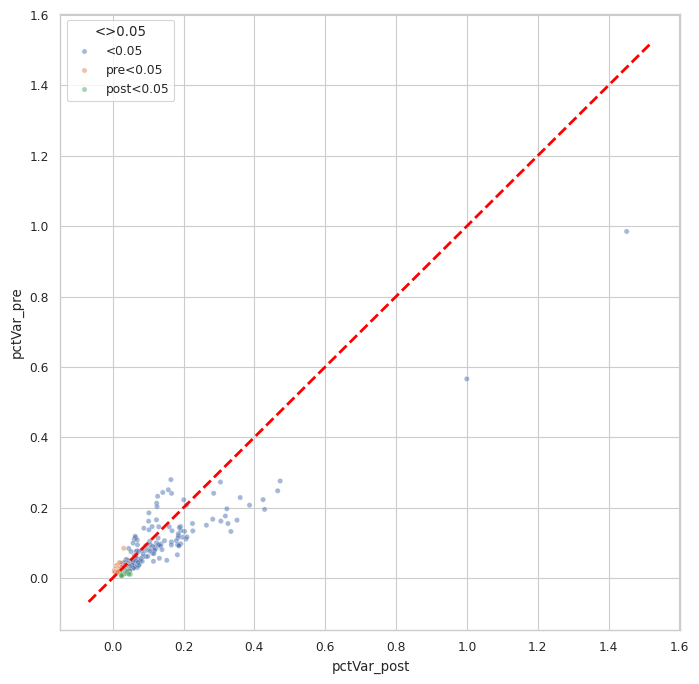

In [58]:
fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(pre_post, x="pctVar_post", y="pctVar_pre", ax=ax, hue=col, s=14, alpha=0.5)
x_min, x_max = plt.xlim()
y_min, y_max = plt.ylim()
min_val = min(x_min, y_min)
max_val = max(x_max, y_max)

plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2)

In [38]:
with pd.option_context('display.max_colwidth', None, 'display.width', 1000):
    print(pre_post.loc[(pre_post.padj_pre < pval_threshold) & (pre_post.padj_post >= pval_threshold), :].sort_values("padj_pre").head(30))

                                                                                       pathway  pctVar_pre      pval_pre      padj_pre  log2err_pre  size_pre  pctVar_post  pval_post  padj_post  log2err_post  size_post    <>0.05
66                                                              REACTOME_FATTY_ACID_METABOLISM    0.084547  1.886394e-07  8.953331e-07     0.690132       158     0.031119   0.074925   0.250684      0.160801        158  pre<0.05
99                                                                 REACTOME_SIGNALING_BY_NTRKS    0.051987  4.686523e-05  1.490314e-04     0.557332       127     0.037480   0.027972   0.127838      0.271289        127  pre<0.05
106  REACTOME_DISEASES_OF_SIGNAL_TRANSDUCTION_BY_GROWTH_FACTOR_RECEPTORS_AND_SECOND_MESSENGERS    0.063855  1.111141e-04  3.302269e-04     0.538434       430     0.065255   0.024975   0.118164      0.287857        430  pre<0.05
113                                                REACTOME_NR1H2_AND_NR1H3_MEDIATED_SIG

In [39]:
with pd.option_context('display.max_colwidth', None, 'display.width', 1000):
    print(pre_post.loc[(pre_post.padj_pre >= pval_threshold) & (pre_post.padj_post < pval_threshold), :].sort_values("padj_post").head(30))

                                                                                                     pathway  pctVar_pre  pval_pre  padj_pre  log2err_pre  size_pre  pctVar_post  pval_post  padj_post  log2err_post  size_post     <>0.05
523                                                       REACTOME_FORMATION_OF_FIBRIN_CLOT_CLOTTING_CASCADE    0.010643  0.109890  0.223526     0.130106        28     0.046257   0.001850   0.003801      0.455060         28  post<0.05
462                                                         REACTOME_COMMON_PATHWAY_OF_FIBRIN_CLOT_FORMATION    0.012353  0.074925  0.173426     0.160801        15     0.043290   0.004722   0.007847      0.407018         15  post<0.05
442                                                                              REACTOME_INTEGRIN_SIGNALING    0.012266  0.066933  0.161542     0.170932        24     0.033153   0.007027   0.010448      0.407018         24  post<0.05
492                                            REACTOME_MODU

In [40]:
with pd.option_context('display.max_colwidth', 100, 'display.width', 1000):
    print(pre_post.loc[(pre_post.padj_pre < pval_threshold) & (pre_post.padj_post < pval_threshold), :].sort_values("padj_post").head(50))

                                                                               pathway  pctVar_pre      pval_pre      padj_pre  log2err_pre  size_pre  pctVar_post     pval_post     padj_post  log2err_post  size_post <>0.05
0                                                    REACTOME_NEUTROPHIL_DEGRANULATION    0.984830  1.000000e-50  3.180000e-48          NaN       450     1.451144  1.000000e-50  2.260000e-48           NaN        450  <0.05
1    REACTOME_IMMUNOREGULATORY_INTERACTIONS_BETWEEN_A_LYMPHOID_AND_A_NON_LYMPHOID_CELL    0.565871  4.392821e-31  6.984585e-29     1.446203       118     0.999865  6.462785e-36  7.302947e-34      1.556544        118  <0.05
2                                                   REACTOME_SIGNALING_BY_INTERLEUKINS    0.275730  3.399012e-22  3.602953e-20     1.212545       402     0.472910  1.867619e-22  1.406940e-20      1.221054        402  <0.05
10                                         REACTOME_CLASS_A_1_RHODOPSIN_LIKE_RECEPTORS    0.195023  1.244188

In [59]:
pre_post.loc[pre_post.pathway.str.contains("proteasome", case=False), :]

,pathway,pctVar_pre,pval_pre,padj_pre,log2err_pre,size_pre,pctVar_post,pval_post,padj_post,log2err_post,size_post,<>0.05
169,REACTOME_PROTEASOME_ASSEMBLY,0.031247,0.002238,0.004115,0.431708,51,0.010186,0.274725,0.538421,0.074176,51,pre<0.05
206,REACTOME_DEGRADATION_OF_GLI1_BY_THE_PROTEASOME,0.028100,0.004945,0.007597,0.407018,45,0.008337,0.350649,0.610369,0.062112,45,pre<0.05


# KEGG

In [60]:
pre = pd.read_csv(os.path.join(INPUT_DIR, "kegg_pre.csv"))
post = pd.read_csv(os.path.join(INPUT_DIR, "kegg_post.csv"))

In [61]:
pre_post = pd.merge(pre, post, on="pathway", suffixes=("_pre", "_post"))

In [62]:
pval_threshold = 0.05

pre_post = pre_post.loc[(pre_post.padj_pre < pval_threshold) | (pre_post.padj_post < pval_threshold),:]

col = f"<>{pval_threshold}"
pre_post[col] = f"<{pval_threshold}"
pre_post.loc[(pre_post.padj_pre < pval_threshold) & (pre_post.padj_post >= pval_threshold), col] = f"pre<{pval_threshold}"
pre_post.loc[(pre_post.padj_pre >= pval_threshold) & (pre_post.padj_post < pval_threshold), col] = f"post<{pval_threshold}"

In [44]:
sns.set_theme(context="paper", style="whitegrid")

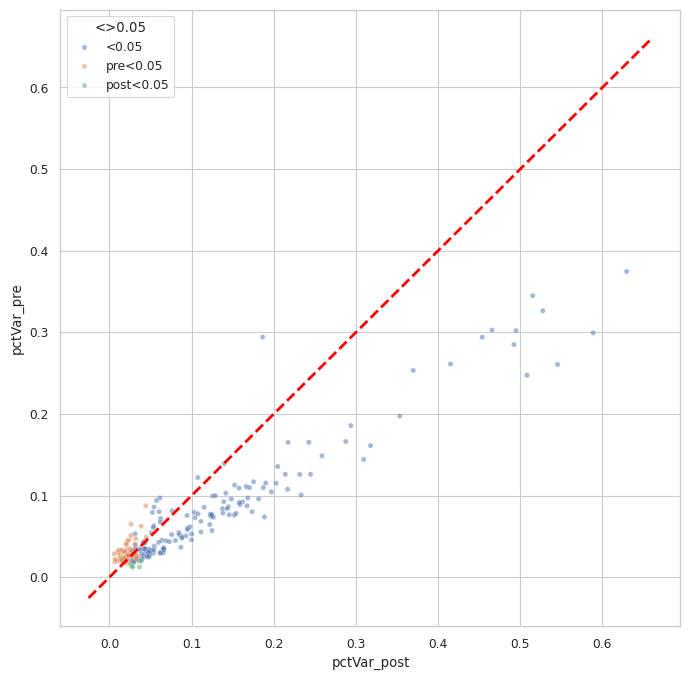

In [45]:
fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(pre_post, x="pctVar_post", y="pctVar_pre", ax=ax, hue=col, s=14, alpha=0.5)
x_min, x_max = plt.xlim()
y_min, y_max = plt.ylim()
min_val = min(x_min, y_min)
max_val = max(x_max, y_max)

plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2)

In [46]:
with pd.option_context('display.max_colwidth', None, 'display.width', 1000):
    print(pre_post.loc[(pre_post.padj_pre < pval_threshold) & (pre_post.padj_post >= pval_threshold), :].sort_values("padj_pre").head(30))

                                                      pathway  pctVar_pre      pval_pre      padj_pre  log2err_pre  size_pre  pctVar_post  pval_post  padj_post  log2err_post  size_post    <>0.05
51                                          Parkinson disease    0.087634  2.605291e-07  9.719740e-07     0.674963       250     0.044294   0.040959   0.081677      0.222056        250  pre<0.05
81                                              Prion disease    0.065025  1.438157e-05  3.402470e-05     0.575610       253     0.026371   0.241758   0.316433      0.080859        253  pre<0.05
83                                         Huntington disease    0.062668  2.108349e-05  4.869282e-05     0.575610       283     0.038603   0.095904   0.155557      0.140406        283  pre<0.05
100         Chemical carcinogenesis - reactive oxygen species    0.048866  2.483546e-04  4.770376e-04     0.498493       209     0.044775   0.029970   0.065547      0.261664        209  pre<0.05
101                      

In [47]:
with pd.option_context('display.max_colwidth', None, 'display.width', 1000):
    print(pre_post.loc[(pre_post.padj_pre >= pval_threshold) & (pre_post.padj_post < pval_threshold), :].sort_values("padj_post").head(30))

                                                                     pathway  pctVar_pre  pval_pre  padj_pre  log2err_pre  size_pre  pctVar_post  pval_post  padj_post  log2err_post  size_post     <>0.05
235  Glycosaminoglycan biosynthesis - chondroitin sulfate / dermatan sulfate    0.013824  0.063936  0.091069     0.175204        21     0.026923   0.010985   0.012518      0.380730         21  post<0.05
250                                                           Bile secretion    0.012421  0.096903  0.130877     0.139600        54     0.036663   0.012031   0.013298      0.380730         54  post<0.05
212                                                     Galactose metabolism    0.016135  0.040959  0.064884     0.222056        27     0.025662   0.015470   0.016361      0.352488         27  post<0.05
211                                             Cornified envelope formation    0.020147  0.039960  0.063898     0.224966       110     0.039016   0.018474   0.019125      0.352488        

In [48]:
with pd.option_context('display.max_colwidth', 100, 'display.width', 1000):
    print(pre_post.loc[(pre_post.padj_pre < pval_threshold) & (pre_post.padj_post < pval_threshold), :].sort_values("padj_post").head(50))

                                                          pathway  pctVar_pre      pval_pre      padj_pre  log2err_pre  size_pre  pctVar_post     pval_post     padj_post  log2err_post  size_post <>0.05
6                          Cytokine-cytokine receptor interaction    0.260762  5.364869e-20  1.486835e-18     1.151221       216     0.545364  6.860061e-24  5.042145e-22      1.262740        216  <0.05
5                                      Osteoclast differentiation    0.299433  2.162690e-20  6.992697e-19     1.160180       127     0.588725  5.425300e-24  5.042145e-22      1.262740        127  <0.05
0                         Neutrophil extracellular trap formation    0.345020  3.931019e-22  7.626177e-20     1.212545       136     0.515072  8.257285e-22  4.046070e-20      1.203975        136  <0.05
7                                     Chemokine signaling pathway    0.285136  6.148049e-20  1.490902e-18     1.151221       171     0.492354  1.587976e-21  5.835810e-20      1.195344        1

In [63]:
pre_post.loc[pre_post.pathway.str.contains("proteasome", case=False), :]

,pathway,pctVar_pre,pval_pre,padj_pre,log2err_pre,size_pre,pctVar_post,pval_post,padj_post,log2err_post,size_post,<>0.05
141,Proteasome,0.030608,0.002904,0.00394,0.431708,45,0.01008,0.264735,0.336125,0.076084,45,pre<0.05


# Hallmark

In [64]:
pre = pd.read_csv(os.path.join(INPUT_DIR, "hallmark_pre.csv"))
post = pd.read_csv(os.path.join(INPUT_DIR, "hallmark_post.csv"))

In [65]:
pre_post = pd.merge(pre, post, on="pathway", suffixes=("_pre", "_post"))

In [66]:
pval_threshold = 0.05

pre_post = pre_post.loc[(pre_post.padj_pre < pval_threshold) | (pre_post.padj_post < pval_threshold),:]

col = f"<>{pval_threshold}"
pre_post[col] = f"<{pval_threshold}"
pre_post.loc[(pre_post.padj_pre < pval_threshold) & (pre_post.padj_post >= pval_threshold), col] = f"pre<{pval_threshold}"
pre_post.loc[(pre_post.padj_pre >= pval_threshold) & (pre_post.padj_post < pval_threshold), col] = f"post<{pval_threshold}"

In [67]:
sns.set_theme(context="paper", style="whitegrid")

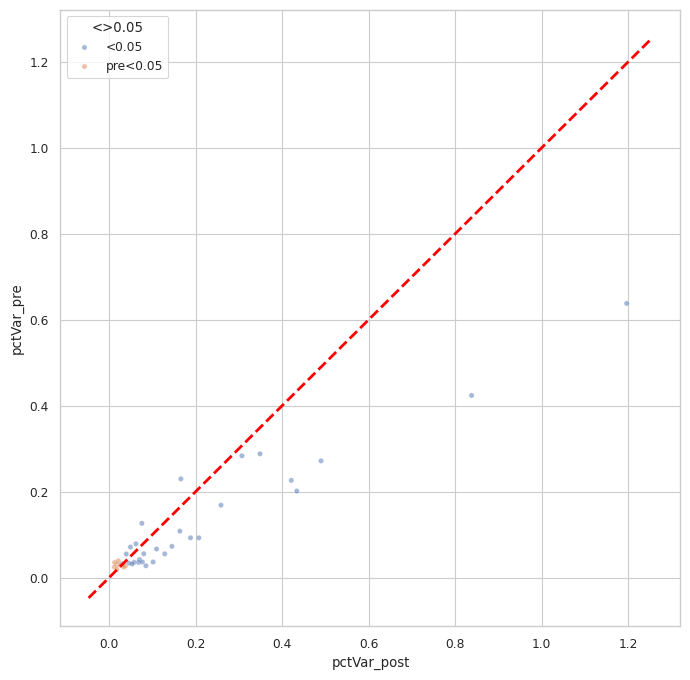

In [68]:
fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(pre_post, x="pctVar_post", y="pctVar_pre", ax=ax, hue=col, s=14, alpha=0.5)
x_min, x_max = plt.xlim()
y_min, y_max = plt.ylim()
min_val = min(x_min, y_min)
max_val = max(x_max, y_max)

plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2)

In [69]:
with pd.option_context('display.max_colwidth', None, 'display.width', 1000):
    print(pre_post.loc[(pre_post.padj_pre < pval_threshold) & (pre_post.padj_post >= pval_threshold), :].sort_values("padj_pre").head(30))

                             pathway  pctVar_pre  pval_pre  padj_pre  log2err_pre  size_pre  pctVar_post  pval_post  padj_post  log2err_post  size_post    <>0.05
21       HALLMARK_TGF_BETA_SIGNALING    0.030705  0.001114  0.001822     0.455060        53     0.018511   0.096903   0.142505      0.139600         53  pre<0.05
22     HALLMARK_BILE_ACID_METABOLISM    0.035351  0.001206  0.001887     0.455060        98     0.012756   0.358641   0.408682      0.061036         98  pre<0.05
24           HALLMARK_MYC_TARGETS_V1    0.039180  0.001519  0.002187     0.455060       199     0.021450   0.305694   0.372798      0.068794        199  pre<0.05
31    HALLMARK_XENOBIOTIC_METABOLISM    0.029211  0.010387  0.011686     0.380730       177     0.026484   0.162837   0.226163      0.103576        177  pre<0.05
32               HALLMARK_PEROXISOME    0.024525  0.012031  0.013125     0.380730        94     0.012039   0.377622   0.419580      0.058594         94  pre<0.05
34  HALLMARK_ESTROGEN_RESPON

In [70]:
with pd.option_context('display.max_colwidth', None, 'display.width', 1000):
    print(pre_post.loc[(pre_post.padj_pre >= pval_threshold) & (pre_post.padj_post < pval_threshold), :].sort_values("padj_post").head(30))

Empty DataFrame
Columns: [pathway, pctVar_pre, pval_pre, padj_pre, log2err_pre, size_pre, pctVar_post, pval_post, padj_post, log2err_post, size_post, <>0.05]
Index: []


In [71]:
with pd.option_context('display.max_colwidth', 100, 'display.width', 1000):
    print(pre_post.loc[(pre_post.padj_pre < pval_threshold) & (pre_post.padj_post < pval_threshold), :].sort_values("padj_post").head(50))

                                       pathway  pctVar_pre      pval_pre      padj_pre  log2err_pre  size_pre  pctVar_post     pval_post     padj_post  log2err_post  size_post <>0.05
0                 HALLMARK_ALLOGRAFT_REJECTION    0.638068  5.712796e-40  2.056607e-38     1.640742       184     1.196685  2.663583e-45  7.458033e-44      1.750650        184  <0.05
1               HALLMARK_INFLAMMATORY_RESPONSE    0.423946  1.362877e-29  2.453179e-28     1.409951       187     0.838144  3.782244e-33  5.295142e-32      1.488540        187  <0.05
4           HALLMARK_INTERFERON_GAMMA_RESPONSE    0.271763  1.534760e-19  1.105027e-18     1.142191       197     0.490034  1.922280e-21  1.794128e-20      1.195344        197  <0.05
6                   HALLMARK_KRAS_SIGNALING_UP    0.226294  4.338824e-17  2.231395e-16     1.057464       181     0.421398  1.143845e-18  6.405534e-18      1.114664        181  <0.05
7                          HALLMARK_COMPLEMENT    0.201529  1.892775e-15  8.517488e-1

In [72]:
pre_post.loc[pre_post.pathway.str.contains("proteasome", case=False), :]

,pathway,pctVar_pre,pval_pre,padj_pre,log2err_pre,size_pre,pctVar_post,pval_post,padj_post,log2err_post,size_post,<>0.05


# GO MF

In [73]:
pre = pd.read_csv(os.path.join(INPUT_DIR, "mf_pre.csv"))
post = pd.read_csv(os.path.join(INPUT_DIR, "mf_post.csv"))

In [74]:
pre_post = pd.merge(pre, post, on="pathway", suffixes=("_pre", "_post"))

In [75]:
pval_threshold = 0.05

pre_post = pre_post.loc[(pre_post.padj_pre < pval_threshold) | (pre_post.padj_post < pval_threshold),:]

col = f"<>{pval_threshold}"
pre_post[col] = f"<{pval_threshold}"
pre_post.loc[(pre_post.padj_pre < pval_threshold) & (pre_post.padj_post >= pval_threshold), col] = f"pre<{pval_threshold}"
pre_post.loc[(pre_post.padj_pre >= pval_threshold) & (pre_post.padj_post < pval_threshold), col] = f"post<{pval_threshold}"

In [76]:
sns.set_theme(context="paper", style="whitegrid")

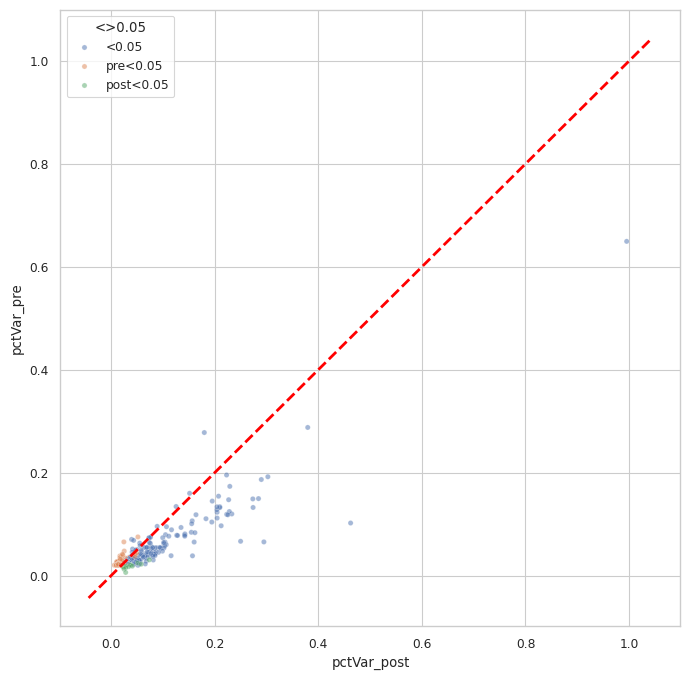

In [77]:
fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(pre_post, x="pctVar_post", y="pctVar_pre", ax=ax, hue=col, s=14, alpha=0.5)
x_min, x_max = plt.xlim()
y_min, y_max = plt.ylim()
min_val = min(x_min, y_min)
max_val = max(x_max, y_max)

plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2)

In [78]:
with pd.option_context('display.max_colwidth', None, 'display.width', 1000):
    print(pre_post.loc[(pre_post.padj_pre < pval_threshold) & (pre_post.padj_post >= pval_threshold), :].sort_values("padj_pre").head(30))

                                                                                             pathway  pctVar_pre  pval_pre  padj_pre  log2err_pre  size_pre  pctVar_post  pval_post  padj_post  log2err_post  size_post    <>0.05
44                                                               GOMF_PROTEIN_SERINE_KINASE_ACTIVITY    0.075558  0.000003  0.000016     0.627257       344     0.052163   0.045954   0.165304      0.208955        344  pre<0.05
59                                                 GOMF_DNA_BINDING_TRANSCRIPTION_ACTIVATOR_ACTIVITY    0.065872  0.000031  0.000111     0.557332       341     0.025060   0.452547   0.666958      0.050193        341  pre<0.05
77                                                                   GOMF_HISTONE_MODIFYING_ACTIVITY    0.048117  0.000092  0.000252     0.538434       177     0.025767   0.138861   0.317457      0.113787        177  pre<0.05
102                                                   GOMF_OXIDOREDUCTASE_ACTIVITY_ACTING_ON_NAD

In [79]:
with pd.option_context('display.max_colwidth', None, 'display.width', 1000):
    print(pre_post.loc[(pre_post.padj_pre >= pval_threshold) & (pre_post.padj_post < pval_threshold), :].sort_values("padj_post").head(30))

                                                                                         pathway  pctVar_pre  pval_pre  padj_pre  log2err_pre  size_pre  pctVar_post  pval_post  padj_post  log2err_post  size_post     <>0.05
224                                                        GOMF_PHOSPHATIDYLETHANOLAMINE_BINDING    0.020647  0.029970  0.100652     0.261664        16     0.038428   0.008295   0.011276      0.380730         16  post<0.05
239  GOMF_OXIDOREDUCTASE_ACTIVITY_ACTING_ON_SINGLE_DONORS_WITH_INCORPORATION_OF_MOLECULAR_OXYGEN    0.017877  0.037962  0.120055     0.231127        17     0.034401   0.010686   0.013981      0.380730         17  post<0.05
270                                                   GOMF_MOLECULAR_FUNCTION_INHIBITOR_ACTIVITY    0.031081  0.059940  0.167876     0.181383       456     0.074254   0.010985   0.014159      0.380730        456  post<0.05
258                                                                  GOMF_GROWTH_FACTOR_ACTIVITY    0.018826

In [80]:
with pd.option_context('display.max_colwidth', 100, 'display.width', 1000):
    print(pre_post.loc[(pre_post.padj_pre < pval_threshold) & (pre_post.padj_post < pval_threshold), :].sort_values("padj_post").head(50))

                                                               pathway  pctVar_pre      pval_pre      padj_pre  log2err_pre  size_pre  pctVar_post     pval_post     padj_post  log2err_post  size_post <>0.05
0                                        GOMF_IMMUNE_RECEPTOR_ACTIVITY    0.649584  6.887658e-37  1.473959e-34     1.576374       138     0.995290  5.320428e-37  9.257544e-35      1.576374        138  <0.05
3                                      GOMF_CYTOKINE_RECEPTOR_ACTIVITY    0.187044  8.503580e-13  4.549416e-11     0.910120        91     0.290309  2.141662e-13  1.863246e-11      0.932595         91  <0.05
5                                                GOMF_INTEGRIN_BINDING    0.149373  8.104836e-12  2.890725e-10     0.875325       154     0.273910  4.966689e-13  2.880679e-11      0.921426        154  <0.05
6                                                GOMF_CYTOKINE_BINDING    0.150000  1.014602e-11  3.101783e-10     0.875325       130     0.284877  7.764158e-13  3.377409e-

In [81]:
pre_post.loc[pre_post.pathway.str.contains("proteasome", case=False), :]

,pathway,pctVar_pre,pval_pre,padj_pre,log2err_pre,size_pre,pctVar_post,pval_post,padj_post,log2err_post,size_post,<>0.05


# Wiki

In [83]:
pre = pd.read_csv(os.path.join(INPUT_DIR, "wiki_pre.csv"))
post = pd.read_csv(os.path.join(INPUT_DIR, "wiki_post.csv"))

In [84]:
pre_post = pd.merge(pre, post, on="pathway", suffixes=("_pre", "_post"))

In [85]:
pval_threshold = 0.05

pre_post = pre_post.loc[(pre_post.padj_pre < pval_threshold) | (pre_post.padj_post < pval_threshold),:]

col = f"<>{pval_threshold}"
pre_post[col] = f"<{pval_threshold}"
pre_post.loc[(pre_post.padj_pre < pval_threshold) & (pre_post.padj_post >= pval_threshold), col] = f"pre<{pval_threshold}"
pre_post.loc[(pre_post.padj_pre >= pval_threshold) & (pre_post.padj_post < pval_threshold), col] = f"post<{pval_threshold}"

In [86]:
sns.set_theme(context="paper", style="whitegrid")

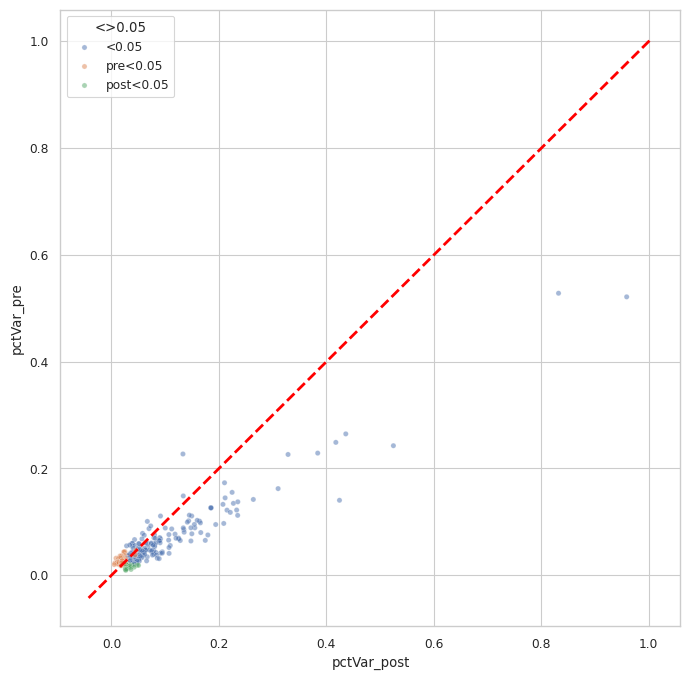

In [87]:
fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(pre_post, x="pctVar_post", y="pctVar_pre", ax=ax, hue=col, s=14, alpha=0.5)
x_min, x_max = plt.xlim()
y_min, y_max = plt.ylim()
min_val = min(x_min, y_min)
max_val = max(x_max, y_max)

plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2)

In [88]:
with pd.option_context('display.max_colwidth', None, 'display.width', 1000):
    print(pre_post.loc[(pre_post.padj_pre < pval_threshold) & (pre_post.padj_post >= pval_threshold), :].sort_values("padj_pre").head(30))

                                                                 pathway  pctVar_pre  pval_pre  padj_pre  log2err_pre  size_pre  pctVar_post  pval_post  padj_post  log2err_post  size_post    <>0.05
103                   WP_CHOLESTEROL_BIOSYNTHESIS_PATHWAY_IN_HEPATOCYTES    0.044322  0.000262  0.000619     0.498493        95     0.024903   0.063936   0.146591      0.175204         95  pre<0.05
112                                                    WP_PPAR_SIGNALING    0.043525  0.000399  0.000872     0.498493        41     0.024442   0.036963   0.104153      0.234393         41  pre<0.05
121                                WP_OMEGA3_OMEGA6_FATTY_ACID_SYNTHESIS    0.043687  0.000600  0.001219     0.477271        15     0.022943   0.026973   0.082562      0.276501         15  pre<0.05
122                          WP_CORTICOTROPINRELEASING_HORMONE_SIGNALING    0.038243  0.000609  0.001228     0.477271        86     0.028071   0.040959   0.110260      0.222056         86  pre<0.05
125       

In [89]:
with pd.option_context('display.max_colwidth', None, 'display.width', 1000):
    print(pre_post.loc[(pre_post.padj_pre >= pval_threshold) & (pre_post.padj_post < pval_threshold), :].sort_values("padj_post").head(30))

                                                                       pathway  pctVar_pre  pval_pre  padj_pre  log2err_pre  size_pre  pctVar_post  pval_post  padj_post  log2err_post  size_post     <>0.05
265  WP_AMPLIFICATION_AND_EXPANSION_OF_ONCOGENIC_PATHWAYS_AS_METASTATIC_TRAITS    0.018496  0.032967  0.073626     0.248911        17     0.050336   0.001114   0.002312      0.455060         17  post<0.05
262                 WP_DEGRADATION_PATHWAY_OF_SPHINGOLIPIDS_INCLUDING_DISEASES    0.018762  0.031968  0.072197     0.252961        16     0.047640   0.003422   0.005328      0.431708         16  post<0.05
255                                                           WP_G13_SIGNALING    0.018645  0.027972  0.065124     0.271289        37     0.040091   0.004127   0.006207      0.407018         37  post<0.05
388                                                WP_GASTRIC_CANCER_NETWORK_1    0.010897  0.119880  0.185830     0.123842        28     0.036393   0.004425   0.006451      0.4070

In [90]:
with pd.option_context('display.max_colwidth', 100, 'display.width', 1000):
    print(pre_post.loc[(pre_post.padj_pre < pval_threshold) & (pre_post.padj_post < pval_threshold), :].sort_values("padj_post").head(50))

                                                                          pathway  pctVar_pre      pval_pre      padj_pre  log2err_pre  size_pre  pctVar_post     pval_post     padj_post  log2err_post  size_post <>0.05
0                                           WP_TYROBP_CAUSAL_NETWORK_IN_MICROGLIA    0.521512  3.874172e-25  9.607947e-23     1.295123        60     0.958834  3.429158e-29  6.549692e-27      1.395187         60  <0.05
1                                      WP_MICROGLIA_PATHOGEN_PHAGOCYTOSIS_PATHWAY    0.528223  2.626295e-23  3.256606e-21     1.246233        40     0.832045  1.853591e-24  1.770179e-22      1.279034         40  <0.05
3                                        WP_CYTOKINECYTOKINE_RECEPTOR_INTERACTION    0.242687  2.042120e-18  1.266115e-16     1.105337       192     0.524735  7.098686e-23  4.519497e-21      1.237897        192  <0.05
9                                            WP_NETWORK_MAP_OF_SARSCOV2_SIGNALING    0.140397  5.884442e-12  1.459342e-10     0.

In [91]:
pre_post.loc[pre_post.pathway.str.contains("proteasome", case=False), :]

,pathway,pctVar_pre,pval_pre,padj_pre,log2err_pre,size_pre,pctVar_post,pval_post,padj_post,log2err_post,size_post,<>0.05
172,WP_PROTEASOME_DEGRADATION,0.028635,0.004201,0.006023,0.407018,61,0.016477,0.120879,0.226367,0.123257,61,pre<0.05
